In [1]:
import numpy as np
import polars as pl
from matplotlib import pyplot as plt
import os
from sklearn.model_selection import train_test_split

In [2]:
def generate_sineinterleave(N=32768, L=100):
    rng = np.random.default_rng(42)
    xs = np.linspace(0, np.pi, L)[None].repeat(N, 0)
    freq1 = rng.random(N) * np.pi + np.pi
    freq2 = rng.random(N) * np.pi * 2 + np.pi
    ys1 = np.sin(xs * freq1[:, None])
    ys2 = np.cos(xs * freq2[:, None])

    mask = rng.random((N, L)) < 0.5
    ys = np.where(mask, ys1, ys2)
    df = pl.DataFrame(
        {
            "time": xs.tolist(),
            "value": ys.tolist(),
            "target": (freq2 - freq1).tolist(),
            "mask": mask.tolist(),
        }
    )
    df_trainval, df_test = train_test_split(df, test_size=0.2, random_state=42)
    df_train, df_val = train_test_split(df_trainval, test_size=0.2, random_state=42)

    df_train = df_train.with_columns(split=pl.lit("train"))
    df_val = df_val.with_columns(split=pl.lit("val"))
    df_test = df_test.with_columns(split=pl.lit("test"))

    return pl.concat([df_train, df_val, df_test])

In [3]:
df = generate_sineinterleave()


DATA_DIR = os.environ["DATA_DIR"] + "/preprocessed"
df.write_parquet(f"{DATA_DIR}/sineinterleave.parquet")

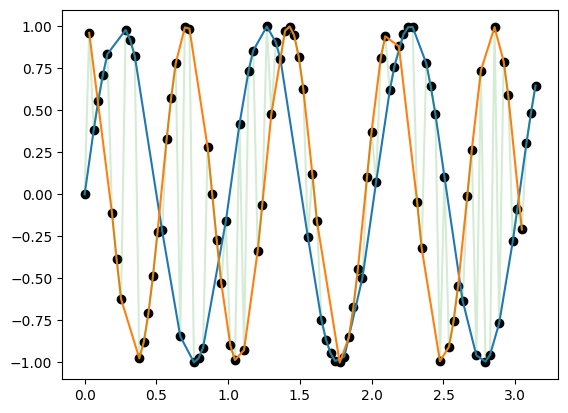

In [4]:
row = df.row(0, named=True)
mask = np.array(row["mask"])
time = np.array(row["time"])
value = np.array(row["value"])
plt.scatter(time, value, c="k")

plt.plot(time[mask], value[mask])
plt.plot(time[~mask], value[~mask])
plt.plot(time, value, alpha=0.2)